# Saliency & Attribution Maps on CIFAR-10

This notebook explores **explainable AI (XAI) techniques for computer vision** using [Captum](https://captum.ai/), applied to a small CNN trained on CIFAR-10.

The goal is to visualize *which pixels* of an input image drive the model's prediction, using four complementary attribution methods:

- **Saliency** — gradient of the output w.r.t. the input pixels.
- **Occlusion** — perturbation-based, measures the prediction drop when patches of the image are masked out.
- **Integrated Gradients** — accumulates gradients along a path from a baseline (black image) to the input.
- **GradCAM** — uses gradients flowing into a chosen convolutional layer to produce a coarse localization map.

**Workflow:** load CIFAR-10 → define/load a pretrained CNN → run each attribution method on a sample image → visualize the resulting heatmaps overlaid on the original image.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
from captum.attr import IntegratedGradients, Saliency, Occlusion, LayerGradCam

## 1. Data

Load the CIFAR-10 dataset (10 classes of 32×32 RGB images) and normalize pixel values to `[-1, 1]` (mean/std of 0.5 per channel).

In [42]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
    ]
)

trainset = CIFAR10(root="./data", train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=4, shuffle=True, num_workers=2)

testset = CIFAR10(root="./data", train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=4, shuffle=False, num_workers=2)

In [43]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## 2. Model

A small CNN (2 conv layers + 3 fully-connected layers, similar to LeNet) that classifies CIFAR-10 images into the 10 classes above.

In [44]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.relu3 = nn.ReLU()
        self.relu4 = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = self.relu3(self.fc1(x))
        x = self.relu4(self.fc2(x))
        x = self.fc3(x)
        return x

In [45]:
net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum=0.9)


## 3. Train or load the model

Since attribution maps only make sense for a model that has actually learned useful features, we either train the CNN from scratch (10 epochs of SGD) or, by default, load the weights already saved in `cifar_torchvision.pt` to skip retraining.

In [46]:
USE_PRETRAINED_MODEL = True

if USE_PRETRAINED_MODEL:
    print("Using existing trained model")
    net.load_state_dict(torch.load('cifar_torchvision.pt'))
else:
    for epoch in range(10):

        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # get the inputs
            inputs, labels = data
            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 2000 == 1999:    # print every 2000 mini-batches
                print('[%d, %5d] loss: %.3f' %
                      (epoch + 1, i + 1, running_loss / 2000))
                running_loss = 0.0

    print('Finished Training')
    torch.save(net.state_dict(), 'models/cifar_torchvision.pt')

Using existing trained model


## 4. Helper functions

Shared utilities reused across all four attribution methods below, so each visualization cell only has to compute its own heatmap and hand it off to a common plotting routine:

- `denormalize_image` / `imshow` — undo the `[-1, 1]` normalization for display.
- `normalize_map` — min-max scale an attribution map to `[0, 1]` for consistent heatmap coloring.
- `attribution_to_heatmap` — turn a raw Captum attribution tensor into a normalized 2D heatmap (used by Saliency, Occlusion, Integrated Gradients).
- `resize_map` — upsample GradCAM's coarse, layer-resolution map back to the original 32×32 image size.
- `build_prediction_title` / `plot_attribution_maps` — build the "True vs. Predicted" title and render the original image next to any number of heatmap overlays.

In [47]:
def denormalize_image(img: torch.Tensor, mean: float = 0.5, std: float = 0.5) -> np.ndarray:
    """Convert a normalized CHW image tensor back into a displayable HWC array.

    Args:
        img: Image tensor of shape (C, H, W), normalized with the given mean/std.
        mean: Mean used when the image was normalized.
        std: Standard deviation used when the image was normalized.

    Returns:
        HWC numpy array with pixel values in [0, 1].
    """
    img = img * std + mean
    npimg = img.cpu().detach().numpy()
    return np.transpose(npimg, (1, 2, 0))


def normalize_map(attr_map: np.ndarray) -> np.ndarray:
    """Min-max normalize a 2D array to the [0, 1] range.

    Args:
        attr_map: Array of attribution values.

    Returns:
        Normalized array with values in [0, 1].
    """
    return (attr_map - attr_map.min()) / (attr_map.max() - attr_map.min())


def attribution_to_heatmap(attr: torch.Tensor) -> np.ndarray:
    """Convert a per-pixel Captum attribution tensor into a normalized 2D heatmap.

    Sums absolute attributions across the channel dimension, then min-max
    normalizes the result.

    Args:
        attr: Attribution tensor of shape (1, C, H, W).

    Returns:
        Normalized 2D heatmap array of shape (H, W).
    """
    heatmap = attr.abs().sum(dim=1).squeeze().cpu().detach().numpy()
    return normalize_map(heatmap)


def resize_map(map_arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    """Resize a 2D map to the given size using bilinear interpolation.

    Args:
        map_arr: 2D array to resize.
        size: Target (height, width).

    Returns:
        Resized 2D array.
    """
    tensor = torch.tensor(map_arr).unsqueeze(0).unsqueeze(0)
    resized = F.interpolate(tensor, size=size, mode='bilinear', align_corners=False)
    return resized.squeeze().numpy()


def build_prediction_title(true_label: str, predicted_label: str) -> str:
    """Build a subplot title showing an image's true and predicted class labels.

    Args:
        true_label: Ground-truth class name.
        predicted_label: Model-predicted class name.

    Returns:
        Multi-line title string.
    """
    return f"Original image\nTrue: {true_label}\nPredicted: {predicted_label}"


def plot_attribution_maps(orig_img: np.ndarray, maps: dict[str, np.ndarray], title: str, alpha: float = 0.35) -> None:
    """Plot an original image alongside one or more attribution heatmaps.

    Each heatmap is overlaid on top of the original image using a 'hot' colormap.

    Args:
        orig_img: Denormalized HWC image array in [0, 1].
        maps: Mapping from map name (used as its subplot title) to a normalized 2D heatmap.
        title: Title for the first (original image) subplot.
        alpha: Opacity of each heatmap overlay.
    """
    n_cols = 1 + len(maps)
    plt.figure(figsize=(5 * n_cols, 5))

    plt.subplot(1, n_cols, 1)
    plt.imshow(orig_img)
    plt.title(title)
    plt.axis('off')

    for i, (map_name, attr_map) in enumerate(maps.items(), start=2):
        plt.subplot(1, n_cols, i)
        plt.imshow(orig_img)
        plt.imshow(attr_map, cmap='hot', alpha=alpha)
        plt.title(map_name)
        plt.colorbar()
        plt.axis('off')

    plt.tight_layout()
    plt.show()


def imshow(img: torch.Tensor) -> None:
    """Display a normalized image tensor.

    Args:
        img: Image tensor of shape (C, H, W), normalized with mean/std 0.5.
    """
    plt.imshow(denormalize_image(img))
    plt.show()

## 5. Pick a sample image

Grab one batch from the test set and single out its first image/label — this is the sample every attribution method below will explain.

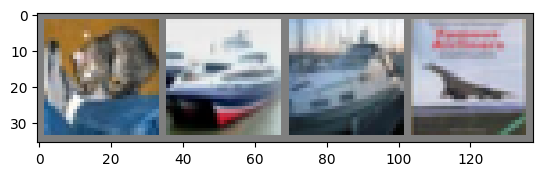

Ground Truth:	   cat  ship  ship plane
Predicted:	   cat  ship  ship plane


In [48]:
dataiter = iter(testloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print("Ground Truth:\t", " ".join('%5s' % classes[labels[j]] for j in range(4)))

outputs = net(images)
_, predicted = torch.max(outputs, 1)
print("Predicted:\t", " ".join('%5s' % classes[labels[j]] for j in range(4)))

In [49]:
input_img = images[0].unsqueeze(0)
input_label = labels[0]

## 6. Saliency & Occlusion

Two attribution methods explained w.r.t. the model's prediction for the true label of the sample image:

- **Saliency**: a single backward pass — the gradient of the target class score w.r.t. each input pixel. Fast but can be noisy.
- **Occlusion**: slides a small window over the image, masking it out (`baselines=0`) and measuring how much the target class score drops. Model-agnostic and robust, but much more expensive (one forward pass per window position).

In [50]:
# 1. Saliency Map
saliency = Saliency(net)
saliency_attr = saliency.attribute(input_img, target=input_label)

In [51]:
# 2. Occlusion
occlusion = Occlusion(net)
occlusion_attr = occlusion.attribute(
    input_img,
    target=input_label,
    strides=(3, 2, 2),
    sliding_window_shapes=(3, 4, 4),
    baselines=0
)

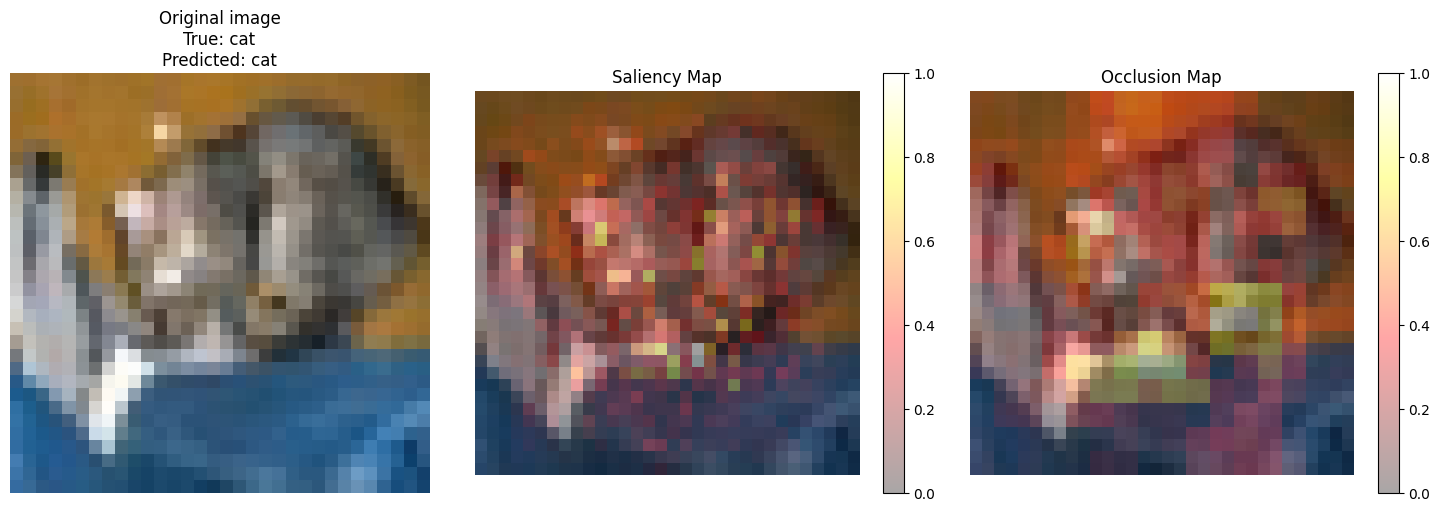

In [52]:
# Visualization
orig_img = denormalize_image(input_img.squeeze())
title = build_prediction_title(classes[labels[0]], classes[predicted[0]])

maps = {
    "Saliency Map": attribution_to_heatmap(saliency_attr),
    "Occlusion Map": attribution_to_heatmap(occlusion_attr),
}

plot_attribution_maps(orig_img, maps, title)

## 7. Integrated Gradients & GradCAM

Two more attribution methods, this time also comparing a pixel-level technique against a layer-level one:

- **Integrated Gradients**: averages gradients along a straight-line path from a baseline (all-black image) to the actual input, addressing some of Saliency's noise/saturation issues.
- **GradCAM**: uses the gradients flowing into a chosen convolutional layer (`conv2` here) to weight that layer's activation maps, producing a coarse, class-discriminative localization map. Because it operates at the resolution of the target layer's feature map, it needs to be upsampled (`resize_map`) back to the original image size before overlaying.

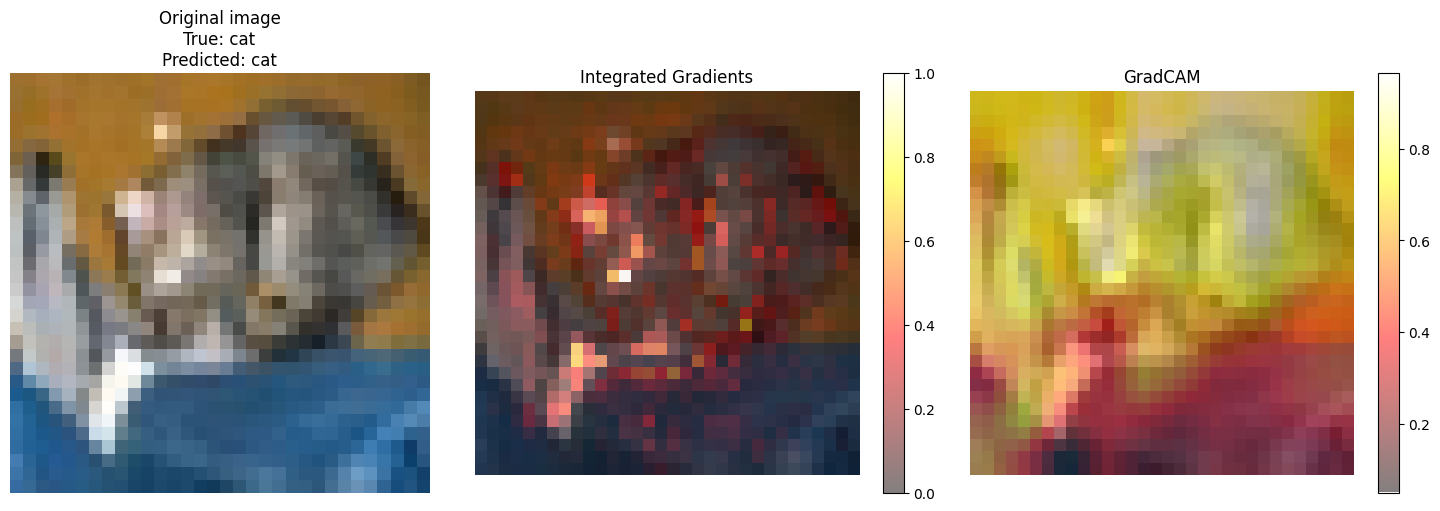

In [53]:
# 1. Integrated Gradients
ig = IntegratedGradients(net)
ig_attr = ig.attribute(input_img, target=input_label, n_steps=50)

# 2. GradCam - layer specific
layer_gradcam = LayerGradCam(net, net.conv2)
gradcam_attr = layer_gradcam.attribute(input_img, target=input_label)

gradcam_map = normalize_map(gradcam_attr.squeeze().cpu().detach().numpy())
gradcam_map = resize_map(gradcam_map, (32, 32))

# Visualization
maps = {
    "Integrated Gradients": attribution_to_heatmap(ig_attr),
    "GradCAM": gradcam_map,
}

plot_attribution_maps(orig_img, maps, title, alpha=0.5)